# GROWL task force — Tutorial 1: Investigating a new dataset

## Dataset: van Son et al. (2022) *"No peaks without valleys"* — model variation `beta0.5 / zetaHG4.5 / Fryer2012-Delayed`

**Welcome to your first real GROWL task!** 🦖 🦕

In the onboarding notebooks you learned how population synthesis works
([Notebook 1](../../../onboarding_growl/tutorial_1_introduction_to_population_synthesis.ipynb)),
how to read and plot a published population
([Notebook 2](../../../onboarding_growl/tutorial_2_analysing_a_population_of_gravitational_wave_sources.ipynb)),
and how merger rates are computed from it
([Notebook 3](../../../onboarding_growl/tutorial_3_cosmic_integration_predicting_merger_rates.ipynb)).

Now you get **a dataset of your own**. The goal of this series of tutorials is to take a published
population synthesis dataset, understand exactly what is in it, and eventually add it to the
**GROWL catalog** in a standard format so that everyone in the task force can use it.

**This first notebook is deliberately simple.** We do the thing you should *always* do before
touching a new dataset: open the file and look. What groups are in it? How many binaries? What
does every column mean? Where does the data come from, and which physics assumptions went into
it? Later notebooks (and later versions of this one) will add analysis questions.

> ⚠️ **This is *not* the same file as in onboarding Notebook 2.** That was the *fiducial* model of
> van Son et al. (2022a, 2023) from Zenodo record `7612755`. The file here comes from a
> **different paper** and is a **model variation**, not the fiducial model. Never assume two files
> from the same authors have the same contents — check.

---

## 📚 Where this dataset comes from

| | |
|---|---|
| 📄 **Paper** — van Son, de Mink, Renzo, Justham, Zapartas, Breivik, Callister, Farr & Conroy (2022), *No peaks without valleys: The stable mass transfer channel for gravitational-wave sources in light of the neutron star–black hole mass gap*, ApJ **940**, 184 | 👉 https://doi.org/10.3847/1538-4357/ac9b0a <br> 👉 https://arxiv.org/abs/2209.13609 |
| 💾 **Data, part 1 of 2 (Zenodo)** — DOI `10.5281/zenodo.7080725` — **this file lives here**, in the archive `faccFIXEDbeta0.5zetaHG4.5RemMassFRYER2012SNDELAYED.tar.gz` (2.2 GB) | 👉 https://zenodo.org/records/7080725 |
| 💾 **Data, part 2 of 2 (Zenodo)** — DOI `10.5281/zenodo.7080164` — contains the *fiducial* model `faccFIXEDbeta0.5zetaHG6.0RemMassFRYER2012SNDELAYED` and the other variations | 👉 https://zenodo.org/records/7080164 |
| 💻 **Analysis code by the authors** | 👉 https://github.com/LiekeVanSon/LowMBH_and_StableChannel |
| 💻 **The simulation code**, COMPAS v02.26.03 ([methods paper](https://arxiv.org/abs/2109.10352)) | 👉 https://compas.science/ |
| 📁 A local copy of the paper (`paper.pdf`) and of the Zenodo README are in the same folder as the data file on the GROWL drive | `/Volumes/GROWL/GROWL_bps/vanSon22noPeaks/` |

> 📌 The Zenodo pages list "arXiv:2209.03385" as the related paper. That is a typo on Zenodo: 2209.03385
> is a *different* van Son et al. paper (the one used in onboarding Notebook 2). The correct paper for
> these datasets is **arXiv:2209.13609**, whose title matches the Zenodo title.

**Skim the abstract of the paper before continuing.** In one sentence: the paper shows that the
*stable mass transfer channel* (binaries that become black holes without ever going through a
common envelope) naturally produces a peak at $\sim 9\,\mathrm{M}_\odot$ in the black hole mass
distribution and a *cut-off* at low masses — which could explain the apparent
[neutron star–black hole mass gap](https://en.wikipedia.org/wiki/Mass_gap) without needing the gap
to be built in at black hole formation.

## 🔧 What is special about *this* model variation?

The paper does a large exploration of uncertain physics. The Zenodo archives are named after the
parameters that were changed. The name of our file's archive decodes as:

| Piece of the name | Parameter | Value in this file | Fiducial value | Meaning (in plain words) |
|---|---|---|---|---|
| `faccFIXED` | accretion efficiency mode | fixed fraction | fixed fraction | The accretor takes a *fixed fraction* $\beta_\mathrm{acc}$ of the mass the donor loses (rather than a fraction set by its thermal timescale). |
| `beta0.5` | $\beta_\mathrm{acc}$, mass transfer efficiency | **0.5** | 0.5 | Half of the transferred mass is kept by the companion; the other half leaves the binary. |
| `zetaHG4.5` | $\zeta_\mathrm{eff} \equiv \mathrm{d}\ln R/\mathrm{d}\ln M$ for Hertzsprung-gap donors | **4.5** | 6.0 | 👈 **This is the one that is different.** It sets how strongly a donor star with a radiative envelope shrinks when it loses mass, and therefore **how easily mass transfer stays stable**. A *lower* $\zeta$ means the donor shrinks less, so mass transfer becomes unstable (→ common envelope) for a *smaller* mass ratio. In the paper's Table 1, $\zeta_\mathrm{eff}=4.5$ corresponds to critical mass ratios $(q_\mathrm{crit,1}, q_\mathrm{crit,2}) = (0.35, 3.55)$ versus $(0.25, 4.32)$ for the fiducial 6.0. Expect **less room for the stable channel** in this file. |
| `RemMassFRYER2012` | remnant mass prescription | Fryer et al. (2012) | Fryer et al. (2012) | The recipe that converts a collapsing stellar core into a neutron star or black hole mass. |
| `SNDELAYED` | supernova engine | "delayed" | "delayed" | The *delayed* explosion model of Fryer et al. (2012) — it does **not** impose a mass gap between neutron stars and black holes (the *rapid* model does). |

So: **everything is fiducial except $\zeta_\mathrm{eff}$, which is lowered from 6.0 to 4.5.**
Section 4 of the paper ("Variations in the mass transfer stability $\zeta_\mathrm{eff}$") discusses
what this does; that is where you should look when you start comparing this file to the fiducial one.

### Glossary of terms used above (see the onboarding notebooks for more)

- **Stable mass transfer** — mass flows from one star to the other through the
  [Roche lobe](https://en.wikipedia.org/wiki/Roche_lobe) in a controlled way; the binary survives and
  typically shrinks moderately.
- **Common envelope (CE)** — mass transfer runs away; the companion is engulfed by the donor's
  envelope and spirals in. Very efficient at shrinking orbits, but the binary may also merge
  prematurely. [Wikipedia](https://en.wikipedia.org/wiki/Common_envelope).
- **Hertzsprung gap (HG)** — the short evolutionary phase after a star exhausts hydrogen in its
  core and before it becomes a giant. Donors in this phase have a *radiative* envelope, which is
  why their response to mass loss ($\zeta$) is treated separately.
- **Double compact object (DCO)** — a binary consisting of two neutron stars and/or black holes.
- **ZAMS** — zero-age main sequence: the moment a star is born. "@ZAMS" columns are initial conditions.


<a id="part1"></a>
# Part 1 — Setup

The file is **3.7 GB** on disk. We never load it all at once; [h5py](https://www.h5py.org/)
lets us read the metadata (group and column names, shapes) instantly and then pull in only the
columns we want.

> 👉 **Change `DATA_PATH`** to wherever the file is on your machine. On the GROWL drive it is at the
> path below. To get your own copy: download `faccFIXEDbeta0.5zetaHG4.5RemMassFRYER2012SNDELAYED.tar.gz`
> from https://zenodo.org/records/7080725 (2.2 GB) and unpack it with
> `tar -xvzf faccFIXEDbeta0.5zetaHG4.5RemMassFRYER2012SNDELAYED.tar.gz` to get `COMPAS_Output_wWeights.h5`.


In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
pd.set_option("display.width", 140)

# >>> CHANGE THIS LINE to wherever the file is on your machine <<<
DATA_PATH = "/Volumes/GROWL/GROWL_bps/vanSon22noPeaks/beta0_5ZETAHG4_5RMS_Delayed/COMPAS_Output_wWeights.h5"

assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
print(f"file size on disk : {os.path.getsize(DATA_PATH) / 1e9:.2f} GB")
print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)


file size on disk : 3.69 GB
numpy 1.26.4 | h5py 3.8.0 | pandas 1.5.3


<a id="part2"></a>
# Part 2 — First look: what is inside the file?

**Always do this before touching a new dataset.** Below we walk the whole
[HDF5](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) hierarchy and print every group,
every dataset (column), its shape and its data type. This is the same code as in onboarding
Notebook 2 — keep it in your toolbox.


In [2]:
with h5py.File(DATA_PATH, "r") as f:
    print("Top-level groups:", list(f.keys()))
    for group in f.keys():
        first_col = list(f[group].keys())[0]
        n_rows = f[group][first_col].shape[0]
        print(f"\nGROUP  {group}   ({n_rows:,} rows, {len(f[group].keys())} columns)")
        print("  " + "-" * 72)
        for col in f[group].keys():
            d = f[group][col]
            print(f"  {col:34s} {str(d.shape):18s} {d.dtype}")


Top-level groups: ['BSE_Double_Compact_Objects', 'BSE_RLOF', 'Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_zBinned']

GROUP  BSE_Double_Compact_Objects   (2,484,379 rows, 17 columns)
  ------------------------------------------------------------------------
  CE_Event_Counter                   (2484379,)         uint32
  Immediate_RLOF>CE                  (2484379,)         uint8
  MT_Donor_Hist(1)                   (2484379,)         |S17
  MT_Donor_Hist(2)                   (2484379,)         |S17
  Mass(1)                            (2484379,)         float64
  Mass(2)                            (2484379,)         float64
  Mass@ZAMS(1)                       (2484379,)         float64
  Mass@ZAMS(2)                       (2484379,)         float64
  Merges_Hubble_Time                 (2484379,)         uint8
  Metallicity@ZAMS(1)                (2484379,)         float64
  Optimistic_CE                      (2484379,)         uint8
  SEED                               (

## 2.1 How to read that output

There are **three** groups. Compare with the file in onboarding Notebook 2, which had **four**:

| Group | One row = | In this file | In the Notebook-2 file |
|---|---|---|---|
| `BSE_System_Parameters` | one simulated binary at birth (ZAMS) | ❌ **absent** | 10,000,000 rows |
| `BSE_Double_Compact_Objects` | one double compact object that formed | ✅ ~2.5 million rows — **the main table** | ~2.5 million rows |
| `BSE_RLOF` | one mass-transfer episode | ✅ ~18 million rows | ~32 million rows |
| `Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_zBinned` | pre-computed merger rates from the authors' cosmic integration | ✅ | ✅ (same name) |

Two things to notice:

1. **`BSE_System_Parameters` is missing.** The authors dropped the table of *all* simulated
   binaries to keep the file small. Consequences: we cannot count directly how many binaries were
   simulated (the Zenodo README says $10^7$, and the largest `SEED` in the file — 9,999,999 — is
   consistent with that), and we cannot look up the birth properties of binaries that did *not*
   become a DCO. Whatever we know about initial conditions comes from the `@ZAMS` columns that
   the authors copied into the DCO table.
2. **The `BSE_RLOF` table is much smaller than in Notebook 2** (18 M vs 32 M rows) even though the
   same number of binaries were run. The authors saved fewer columns and, as we will see, the
   rows only cover binaries that interacted. The columns are also different: this file records
   the masses and eccentricity *before* (`<MT`) and *after* (`>MT`) each episode.

> 📌 `BSE` = **B**inary **S**tellar **E**volution. `RLOF` = **R**oche **L**obe **O**ver**F**low,
> i.e. mass transfer. `<MT` / `>MT` = *before* / *after* the mass transfer episode. `(1)` / `(2)`
> refer to the initially more / less massive star, **not** to the final mass ordering.

## 2.2 Every column, and what it means

### `BSE_Double_Compact_Objects` (17 columns)

| Column | Type | Meaning |
|---|---|---|
| `SEED` | uint64 | Unique ID of the binary. The same `SEED` in `BSE_RLOF` refers to the same binary — this is how you join tables. |
| `Mass(1)`, `Mass(2)` | float | Final masses of the two compact objects, in M$_\odot$. **Not sorted** — `Mass(1)` belongs to the initially more massive star. |
| `Mass@ZAMS(1)`, `Mass@ZAMS(2)` | float | Birth masses of the two stars, in M$_\odot$. |
| `Stellar_Type(1)`, `Stellar_Type(2)` | int | Final stellar type, using the Hurley et al. (2000) codes: **13 = neutron star, 14 = black hole**. |
| `Stellar_Type@ZAMS(1)`, `Stellar_Type@ZAMS(2)` | int | Stellar type at birth: **1 = main-sequence star**, 16 = "chemically homogeneous" star (a rapidly rotating star that stays compact and hot; a rare special case). |
| `Metallicity@ZAMS(1)` | float | [Metallicity](https://en.wikipedia.org/wiki/Metallicity) $Z$ (mass fraction of elements heavier than helium) at birth; the Sun has $Z_\odot \approx 0.014$. Both stars share the same value. |
| `Merges_Hubble_Time` | 0/1 | 1 if the binary merges within the age of the Universe (a Hubble time, ~13.8 Gyr) — i.e. it is a gravitational-wave source. |
| `CE_Event_Counter` | int | Number of common-envelope episodes the binary went through. **0 means it formed through the stable mass transfer channel** — the channel the paper is about. |
| `MT_Donor_Hist(1)`, `MT_Donor_Hist(2)` | string | The *stellar types of star (1)/(2) each time it acted as a donor*, joined with dashes, e.g. `"2-8"` = it donated once as a Hertzsprung-gap star (2) and once as a stripped helium star (8). `"NA"` = never a donor. |
| `Immediate_RLOF>CE` | 0/1 | Flag: the binary started mass transfer immediately after a common envelope. (All zero in this file — such systems were removed.) |
| `Optimistic_CE` | 0/1 | Flag: a common envelope with a Hertzsprung-gap donor, which survives only under the "optimistic" assumption. (All zero here — the authors use the *pessimistic* assumption, so these systems are excluded.) |
| `mixture_weight` | float | ⚖️ **The statistical weight** from adaptive importance sampling (STROOPWAFEL). See onboarding Notebook 2, §1.4: **never count rows, always sum weights.** |

### `BSE_RLOF` (11 columns) — one row per mass-transfer episode

| Column | Meaning |
|---|---|
| `SEED` | Which binary. Repeats once per episode. |
| `MT_Event_Counter` | 1 for the binary's first mass-transfer episode, 2 for its second, etc. |
| `Mass(1)<MT`, `Mass(2)<MT` | Masses (M$_\odot$) just **before** the episode. |
| `Mass(1)>MT`, `Mass(2)>MT` | Masses just **after** the episode. The difference tells you how much was transferred and how much was lost. |
| `Eccentricity<MT`, `Eccentricity>MT` | Orbital eccentricity before / after. |
| `RLOF(1)>MT`, `RLOF(2)>MT` | 1 if star (1) / (2) was overflowing its Roche lobe (i.e. was the donor) at the end of the episode. |
| `CEE>MT` | 1 if this episode was a **common envelope** rather than stable mass transfer. |

### `Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_zBinned` (4 datasets)

The group name encodes the metallicity-dependent star-formation-history parameters
($\mu_0, \mu_z, \alpha, \sigma_0, \sigma_z$) used in the cosmic integration — see onboarding Notebook 3.

| Dataset | Shape | Meaning |
|---|---|---|
| `redshifts` | (201,) | Edges of the 200 redshift bins, $z = 0, 0.05, \dots, 10$. |
| `DCOmask` | (2,484,379,) bool | Which rows of the DCO table were included in the rate calculation. In this file it is exactly `Merges_Hubble_Time == 1`. |
| `merger_rate` | (1,401,406 × 200) | Merger rate of *each* merging DCO in *each* redshift bin, in Gpc$^{-3}$ yr$^{-1}$. Row $i$ corresponds to the $i$-th `True` entry of `DCOmask`. |
| `merger_rate_z0` | (1,401,406,) | The same, at $z=0$ only. Summing this column gives the total local merger rate of all DCOs. |


<a id="part3"></a>
# Part 3 — Load the double compact object table

The DCO table is small enough (2.5 M rows × 17 columns) to load entirely into a pandas
`DataFrame`. The two string columns are stored as raw bytes in HDF5, so we decode them.


In [3]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["BSE_Double_Compact_Objects"]
    dco = pd.DataFrame({col: g[col][()] for col in g.keys()})

# HDF5 stores strings as fixed-width bytes: decode and strip the padding
for col in ["MT_Donor_Hist(1)", "MT_Donor_Hist(2)"]:
    dco[col] = dco[col].str.decode("utf-8").str.strip()

print(f"rows (double compact objects) : {len(dco):,}")
print(f"unique SEEDs                  : {dco.SEED.nunique():,}   (one row per binary? {dco.SEED.nunique() == len(dco)})")
print(f"largest SEED                  : {dco.SEED.max():,}   (consistent with 10^7 binaries simulated)")
print(f"sum of mixture_weight         : {dco.mixture_weight.sum():,.1f}")
print(f"memory used                   : {dco.memory_usage(deep=True).sum() / 1e6:.0f} MB")
dco.head()


rows (double compact objects) : 2,484,379
unique SEEDs                  : 2,484,379   (one row per binary? True)
largest SEED                  : 9,999,999   (consistent with 10^7 binaries simulated)
sum of mixture_weight         : 152,199.8
memory used                   : 486 MB


,CE_Event_Counter,Immediate_RLOF>CE,MT_Donor_Hist(1),MT_Donor_Hist(2),Mass(1),Mass(2),Mass@ZAMS(1),Mass@ZAMS(2),Merges_Hubble_Time,Metallicity@ZAMS(1),Optimistic_CE,SEED,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),mixture_weight
0,0,0,NA,NA,22.468879,15.670067,60.191210,43.874020,0,0.000972,0,108,14,14,1,1,0.061415
1,1,0,4,4,5.493761,5.418732,28.694096,27.571090,0,0.001871,0,141,14,14,1,1,0.589886
2,0,0,NA,NA,15.313613,13.934535,49.169637,45.553791,0,0.002815,0,148,14,14,1,1,3.174603
3,0,0,NA,NA,19.193315,16.619624,110.418333,75.686847,0,0.008218,0,191,14,14,1,1,3.174603
4,0,0,NA,NA,16.737945,15.186515,56.257165,37.696133,0,0.003565,0,212,14,14,1,1,0.013476


## 3.1 Summary statistics of every column

`describe()` gives min / max / mean / percentiles for the numeric columns. This is a fast way to
spot units and sanity problems (a negative mass, a metallicity of 5, ...).


In [4]:
numeric_cols = [c for c in dco.columns if c not in ("SEED", "MT_Donor_Hist(1)", "MT_Donor_Hist(2)")]
pd.set_option("display.float_format", "{:.4g}".format)
dco[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
CE_Event_Counter,2.484e+06,0.6279,0.5052,0,0,1,1,2
Immediate_RLOF>CE,2.484e+06,0,0,0,0,0,0,0
Mass(1),2.484e+06,16.86,5.823,1.26,14.26,16,18.42,163.2
Mass(2),2.484e+06,11.82,7.05,1.26,7.321,10.33,14.59,143.2
Mass@ZAMS(1),2.484e+06,47.92,14.05,5.062,40.78,44.19,49.93,150
Mass@ZAMS(2),2.484e+06,32.54,14.36,1.688,24.82,30.27,35.25,149.6
Merges_Hubble_Time,2.484e+06,0.5641,0.4959,0,0,1,1,1
Metallicity@ZAMS(1),2.484e+06,0.001069,0.0018,0.0001,0.0002177,0.0004665,0.001093,0.02999
Optimistic_CE,2.484e+06,0,0,0,0,0,0,0
Stellar_Type(1),2.484e+06,14,0.06396,13,14,14,14,14


**Things worth noticing in that table** (check them against the numbers you see):

- `Mass(1)` and `Mass(2)` run from ~1.3 M$_\odot$ (a light neutron star) to well above 100 M$_\odot$.
  The very heavy black holes come from very massive, very low-metallicity stars; whether they
  actually *merge* is a separate question (`Merges_Hubble_Time`).
- `Metallicity@ZAMS(1)` spans $10^{-4}$ to $0.03$ — the authors sampled metallicity
  *continuously* (log-uniformly), not on a discrete grid like some other datasets.
- `Immediate_RLOF>CE` and `Optimistic_CE` are identically zero — those flags carry no information
  here, but the fact that they are zero tells you the sample selection the authors applied.
- `mixture_weight` varies by a factor of ~2000 between the lightest- and heaviest-weighted rows.
  That is the size of the sampling bias you would introduce by counting rows.

## 3.2 The categorical columns: stellar types and donor histories


In [5]:
HURLEY = {1: "MS", 2: "HG", 3: "GB", 4: "CHeB", 5: "EAGB", 6: "TPAGB", 7: "HeMS", 8: "HeHG",
          9: "HeGB", 10: "HeWD", 11: "COWD", 12: "ONeWD", 13: "NS", 14: "BH", 15: "massless remnant",
          16: "CHE (chemically homogeneous)"}

def value_table(series, labels=None):
    '''Row counts and weighted counts for each distinct value of a column.'''
    t = (pd.DataFrame({"value": series, "w": dco.mixture_weight})
           .groupby("value").agg(rows=("w", "size"), weighted=("w", "sum")))
    t["rows %"] = 100 * t.rows / t.rows.sum()
    t["weighted %"] = 100 * t.weighted / t.weighted.sum()
    if labels is not None:
        t.insert(0, "label", [labels.get(v, "?") for v in t.index])
    return t

for col in ["Stellar_Type(1)", "Stellar_Type(2)", "Stellar_Type@ZAMS(1)", "Stellar_Type@ZAMS(2)"]:
    print(f"\n=== {col} ===")
    print(value_table(dco[col], HURLEY).round(2).to_string())

for col in ["Merges_Hubble_Time", "CE_Event_Counter", "Immediate_RLOF>CE", "Optimistic_CE"]:
    print(f"\n=== {col} ===")
    print(value_table(dco[col]).round(2).to_string())



=== Stellar_Type(1) ===
      label     rows  weighted  rows %  weighted %
value                                             
13       NS    10206 2.521e+04    0.41       16.56
14       BH  2474173  1.27e+05   99.59       83.44

=== Stellar_Type(2) ===
      label     rows  weighted  rows %  weighted %
value                                             
13       NS    61822 3.064e+04    2.49       20.13
14       BH  2422557 1.216e+05   97.51       79.87

=== Stellar_Type@ZAMS(1) ===
                              label     rows  weighted  rows %  weighted %
value                                                                     
1                                MS  2477716 1.517e+05   99.73       99.66
16     CHE (chemically homogeneous)     6663       512    0.27        0.34

=== Stellar_Type@ZAMS(2) ===
                              label     rows  weighted  rows %  weighted %
value                                                                     
1                               

In [6]:
# The donor-history strings: the ten most common values for each star
for col in ["MT_Donor_Hist(1)", "MT_Donor_Hist(2)"]:
    print(f"\n=== {col} (top 10) ===")
    print(value_table(dco[col]).sort_values("rows", ascending=False).head(10).round(2).to_string())



=== MT_Donor_Hist(1) (top 10) ===
          rows  weighted  rows %  weighted %
value                                       
NA     1310605 8.989e+04   52.75       59.06
2       903652 2.743e+04   36.37       18.02
4       244920 1.241e+04    9.86        8.15
1-2      10607     960.7    0.43        0.63
5         6765      1408    0.27        0.93
2-8       5308 1.679e+04    0.21       11.03
4-8       1482     89.22    0.06        0.06
2-9        530      1683    0.02        1.11
1-2-8      465      1476    0.02        0.97
4-7-8       10      0.26       0           0

=== MT_Donor_Hist(2) (top 10) ===
          rows  weighted  rows %  weighted %
value                                       
4      1436693 1.441e+04   57.83        9.47
NA      531955 8.966e+04   21.41       58.91
2       438551 1.856e+04   17.65        12.2
5        17972      3072    0.72        2.02
4-8      17428      7287     0.7        4.79
4-7      12477     162.2     0.5        0.11
4-7-8    12067       173    0.

**How to read the donor histories.** The numbers are Hurley stellar-type codes at the moment the
star was the *donor*: `1` = main sequence, `2` = Hertzsprung gap, `4` = core helium burning,
`8` = stripped helium star past its main sequence, ... . A history of `"2"` for star (1) means:
star (1) filled its Roche lobe exactly once, while crossing the Hertzsprung gap — the classic
"case B" mass transfer. `"NA"` means the star never donated mass at all. Because
$\zeta_\mathrm{eff}$ is *the* parameter that governs Hertzsprung-gap donors, and this file
lowers it, these histories are where this model variation leaves its fingerprint.

## 3.3 The census: what kinds of double compact objects, and how many merge?

Here we count **both** ways, rows and weights, exactly as in onboarding Notebook 2 — so you see the
sampling bias with your own eyes.


In [7]:
BH, NS = 14, 13

is_bh1, is_bh2 = dco["Stellar_Type(1)"] == BH, dco["Stellar_Type(2)"] == BH
dco["is_BBH"]  = is_bh1 & is_bh2
dco["is_BHNS"] = is_bh1 ^ is_bh2            # exactly one is a black hole
dco["is_BNS"]  = ~is_bh1 & ~is_bh2
dco["merges"]  = dco["Merges_Hubble_Time"] == 1
dco["w"]       = dco["mixture_weight"]

# masses sorted so that m1 >= m2, the observer's convention
dco["m1"] = np.maximum(dco["Mass(1)"], dco["Mass(2)"])
dco["m2"] = np.minimum(dco["Mass(1)"], dco["Mass(2)"])

wtot = dco.w.sum()
print(f"{'':10s} {'rows':>10s} {'rows %':>8s} {'weighted':>11s} {'wtd %':>7s} | {'merging rows':>12s} {'merging wtd':>12s} {'merging frac (wtd)':>18s}")
print("-" * 100)
for name, m in [("BH+BH", dco.is_BBH), ("BH+NS", dco.is_BHNS), ("NS+NS", dco.is_BNS)]:
    mm = m & dco.merges
    print(f"{name:10s} {m.sum():10,} {100*m.mean():7.2f}% {dco.w[m].sum():11,.0f} {100*dco.w[m].sum()/wtot:6.2f}% |"
          f" {mm.sum():12,} {dco.w[mm].sum():12,.0f} {100*dco.w[mm].sum()/dco.w[m].sum():17.1f}%")
print("-" * 100)
mm = dco.merges
print(f"{'ALL':10s} {len(dco):10,} {100.0:7.2f}% {wtot:11,.0f} {100.0:6.2f}% |"
      f" {mm.sum():12,} {dco.w[mm].sum():12,.0f} {100*dco.w[mm].sum()/wtot:17.1f}%")

print(f"\nMerging DCOs formed through the STABLE channel (no common envelope), weighted fraction:")
for name, m in [("BH+BH", dco.is_BBH), ("BH+NS", dco.is_BHNS), ("NS+NS", dco.is_BNS)]:
    mm = m & dco.merges
    stable = mm & (dco.CE_Event_Counter == 0)
    print(f"   {name:8s} {100*dco.w[stable].sum()/dco.w[mm].sum():5.1f}%   ({stable.sum():,} rows)")


                 rows   rows %    weighted   wtd % | merging rows  merging wtd merging frac (wtd)
----------------------------------------------------------------------------------------------------
BH+BH       2,420,238   97.42%     121,265  79.68% |    1,366,826       10,740               8.9%
BH+NS          56,254    2.26%       6,018   3.95% |       33,000          822              13.7%
NS+NS           7,887    0.32%      24,916  16.37% |        1,580        4,986              20.0%
----------------------------------------------------------------------------------------------------
ALL         2,484,379  100.00%     152,200 100.00% |    1,401,406       16,548              10.9%

Merging DCOs formed through the STABLE channel (no common envelope), weighted fraction:
   BH+BH      6.6%   (34,754 rows)
   BH+NS      6.1%   (1,407 rows)
   NS+NS      0.0%   (0 rows)


## 3.4 Quick-look plot: the black hole mass distribution

Not analysis yet — just a picture to confirm the file behaves sensibly. Weighted, merging binary
black holes only, $m_1 \ge m_2$. The dashed line marks the $\sim 9\,\mathrm{M}_\odot$ peak the paper is
about, and the shaded band is the part of the $m_1$ distribution that comes from the **stable
channel** (no common envelope) — the channel the paper is about. With $\zeta_\mathrm{eff}$ lowered
to 4.5 that band is small (§3.3 gave ~7% by weight). Compare with the corresponding plot in
onboarding Notebook 2 for the fiducial model.


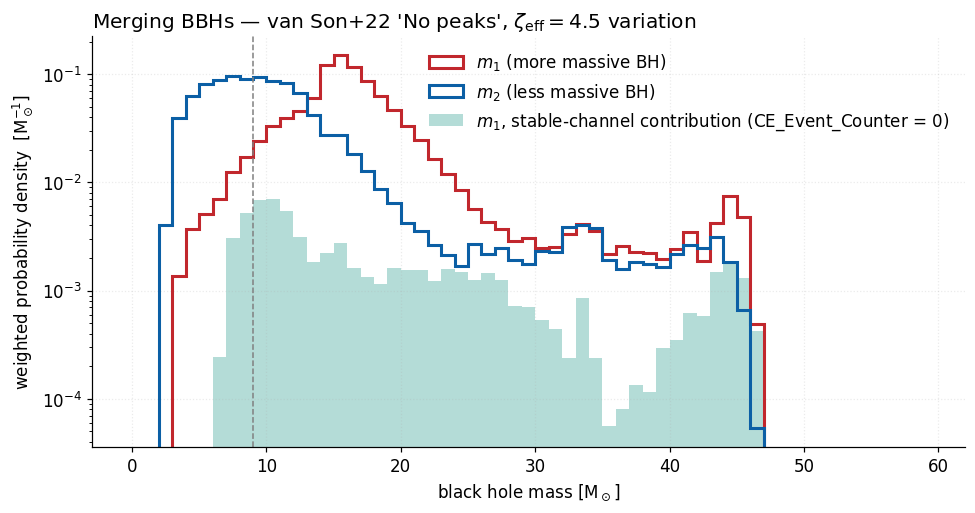

In [8]:
bbh = dco[dco.is_BBH & dco.merges]
bins = np.arange(0, 60, 1.0)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(bbh.m1, bins=bins, weights=bbh.w, density=True, histtype="step", lw=2, color="#C1272D",
        label=r"$m_1$ (more massive BH)")
ax.hist(bbh.m2, bins=bins, weights=bbh.w, density=True, histtype="step", lw=2, color="#0B5FA5",
        label=r"$m_2$ (less massive BH)")
# contribution of the stable channel (no common envelope) to the SAME normalised m1 density
stable = bbh.CE_Event_Counter == 0
h_stable, _ = np.histogram(bbh.m1[stable], bins=bins, weights=bbh.w[stable])
ax.stairs(h_stable / (bbh.w.sum() * np.diff(bins)), bins, fill=True, color="#2A9D8F", alpha=0.35,
          label=r"$m_1$, stable-channel contribution (CE_Event_Counter = 0)")
ax.axvline(9, ls="--", color="grey", lw=1)
ax.set_yscale("log")
ax.set_xlabel(r"black hole mass [M$_\odot$]")
ax.set_ylabel("weighted probability density  [M$_\\odot^{-1}$]")
ax.set_title(r"Merging BBHs — van Son+22 'No peaks', $\zeta_\mathrm{eff}=4.5$ variation", loc="left")
ax.legend()
plt.tight_layout()
plt.show()


<a id="part4"></a>
# Part 4 — The mass-transfer table (`BSE_RLOF`)

18 million rows is a lot; we read only three integer columns (~200 MB) to answer: *how many
binaries interacted, how often, and how often was it a common envelope?* Loading the mass columns
is left for later questions.


In [9]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["BSE_RLOF"]
    rlof = pd.DataFrame({c: g[c][()] for c in ["SEED", "MT_Event_Counter", "CEE>MT"]})

n_binaries_interacting = rlof.SEED.nunique()
print(f"mass-transfer episodes recorded        : {len(rlof):,}")
print(f"distinct binaries that interacted       : {n_binaries_interacting:,}  (of 10,000,000 simulated -> {n_binaries_interacting/1e7:.0%})")
print(f"episodes that were a common envelope    : {rlof['CEE>MT'].sum():,}  ({rlof['CEE>MT'].mean():.1%} of episodes, unweighted)")
print(f"binaries in BSE_RLOF that became a DCO  : {rlof.SEED.isin(dco.SEED).sum():,} episodes, "
      f"{rlof.SEED[rlof.SEED.isin(dco.SEED)].nunique():,} binaries")
print(f"DCOs with no BSE_RLOF entry at all      : {(~dco.SEED.isin(rlof.SEED)).sum():,}  (never interacted)")

print("\nNumber of mass-transfer episodes per binary (unweighted; only binaries that interacted):")
n_ep = rlof.groupby("SEED")["MT_Event_Counter"].max()
print(n_ep.value_counts().sort_index().head(10).to_string())


mass-transfer episodes recorded        : 18,300,339
distinct binaries that interacted       : 7,064,170  (of 10,000,000 simulated -> 71%)
episodes that were a common envelope    : 4,296,363  (23.5% of episodes, unweighted)
binaries in BSE_RLOF that became a DCO  : 3,560,975 episodes, 2,141,761 binaries
DCOs with no BSE_RLOF entry at all      : 342,618  (never interacted)

Number of mass-transfer episodes per binary (unweighted; only binaries that interacted):
1     4478706
2     1845466
3      261578
4       65188
5        7016
6       10161
7       17777
8       20274
9       26037
10      29307


> ⚠️ These `BSE_RLOF` counts are **unweighted** — the RLOF table has no `mixture_weight` column.
> To weight an episode you must join on `SEED` to the DCO table (`dco.set_index("SEED").w`), which
> only works for binaries that became a DCO. The ~4.9 million interacting binaries that did *not*
> become a DCO have no weight anywhere in this file. Keep that in mind before making claims about
> "all binaries".

<a id="part5"></a>
# Part 5 — The pre-computed rates group

The authors already did a cosmic integration (onboarding Notebook 3) for one choice of
star-formation history. We only check the shapes and the headline number here.


In [10]:
RATES_GROUP = "Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_zBinned"
with h5py.File(DATA_PATH, "r") as f:
    g = f[RATES_GROUP]
    z_edges  = g["redshifts"][()]
    dco_mask = g["DCOmask"][()]
    rate_z0  = g["merger_rate_z0"][()]
    rate_shape = g["merger_rate"].shape

print(f"redshift bin edges : {len(z_edges)} values from z={z_edges[0]} to z={z_edges[-1]} (step {z_edges[1]-z_edges[0]})")
print(f"merger_rate shape  : {rate_shape}  -> (number of DCOs included) x (number of redshift bins)")
print(f"DCOmask            : {dco_mask.sum():,} of {len(dco_mask):,} DCOs included")
print(f"DCOmask == merging?: {np.array_equal(dco_mask, dco.merges.values)}")

# total local (z=0) merger rate, split by DCO type
included = dco[dco_mask].reset_index(drop=True)
included["rate_z0"] = rate_z0
print(f"\nTotal merger rate at z=0 : {rate_z0.sum():7.1f} Gpc^-3 yr^-1")
for name, m in [("BH+BH", included.is_BBH), ("BH+NS", included.is_BHNS), ("NS+NS", included.is_BNS)]:
    print(f"   {name:8s} {included.rate_z0[m].sum():7.1f} Gpc^-3 yr^-1")


redshift bin edges : 201 values from z=0.0 to z=10.0 (step 0.05)
merger_rate shape  : (1401406, 200)  -> (number of DCOs included) x (number of redshift bins)
DCOmask            : 1,401,406 of 2,484,379 DCOs included
DCOmask == merging?: True

Total merger rate at z=0 :   195.1 Gpc^-3 yr^-1
   BH+BH       36.1 Gpc^-3 yr^-1
   BH+NS        8.8 Gpc^-3 yr^-1
   NS+NS      150.2 Gpc^-3 yr^-1


> 🔍 **Sanity check against observations.** LIGO/Virgo/KAGRA infer a local BBH merger rate of
> order $10$–$30\,\mathrm{Gpc^{-3}\,yr^{-1}}$ (GWTC-3, [Abbott et al. 2023](https://arxiv.org/abs/2111.03634)),
> and the paper's Figure 3 shows how the rate from the stable channel changes with
> $\zeta_\mathrm{eff}$. Is the number above in the right ballpark? Which DCO type dominates?
> (Rates for BNS and BHNS in COMPAS-based models are known to be sensitive to the supernova
> kick and remnant prescriptions — a reason this dataset is interesting.)

---

<a id="part6"></a>
# Part 6 — Questions for you

*(To be added — this section will be extended with the analysis questions for this dataset.)*

---

<a id="summary"></a>
# Summary card for the GROWL catalog

Fill this in as you go; it is the information we will need to register the dataset.

| Field | Value |
|---|---|
| Dataset name | van Son et al. 2022 "No peaks without valleys" — variation `faccFIXEDbeta0.5zetaHG4.5RemMassFRYER2012SNDELAYED` |
| Paper | ApJ 940, 184 — https://doi.org/10.3847/1538-4357/ac9b0a — arXiv:2209.13609 |
| Data DOI | 10.5281/zenodo.7080725 (part 1 of 2); fiducial model in 10.5281/zenodo.7080164 |
| Code | COMPAS v02.26.03; https://github.com/LiekeVanSon/LowMBH_and_StableChannel |
| File | `COMPAS_Output_wWeights.h5`, 3.7 GB, HDF5 |
| Binaries simulated | $10^7$ (from README; `BSE_System_Parameters` not included) |
| Double compact objects | 2,484,379 rows; sum of weights ≈ 152,200 |
| Merging within a Hubble time | 1,401,406 rows |
| Groups | `BSE_Double_Compact_Objects`, `BSE_RLOF`, `Rates_...` |
| Sampling | adaptive importance sampling (STROOPWAFEL) → use `mixture_weight` |
| Metallicity | continuous, $10^{-4} \le Z \le 0.03$ |
| Physics that differs from the paper's fiducial model | $\zeta_\mathrm{eff} = 4.5$ (fiducial 6.0) |
| Known quirks | no `BSE_System_Parameters`; `Optimistic_CE` and `Immediate_RLOF>CE` all zero; RLOF table has no weights |
